# Bidaye Data

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_joint_data(file):
    joint_data = pl.read_csv('data/bidaye/' + file + '.csv')
    joint_data = joint_data.to_numpy()
    joint_data[:,1] = joint_data[:,1].astype(float)
    joint_data[:,1] = joint_data[:,1] - np.min(joint_data[:,1])
    return joint_data
th_cx_flex_data = get_joint_data('hind_air_th_cx_flex')
print(th_cx_flex_data)

[[-0.474000703903631 0.16950768417349593]
 [-0.45435011373286616 0.14994910523039984]
 [-0.43467829020187 0.06780307366939908]
 [-0.41503079656280556 0.05737183156641379]
 [-0.3953744556903114 0.020862484205967036]
 [-0.37572342315787505 0.0]
 [-0.3560794684121825 0.0]
 [-0.33645143868666344 0.046940589463428495]
 [-0.3168110228343428 0.05737183156641379]
 [-0.29716706808865023 0.05737183156641379]
 [-0.27755009740491837 0.13691005260167088]
 [-0.25791852878602745 0.17341939996211408]
 [-0.23829801920892363 0.24252637889438589]
 [-0.218674855461791 0.3038099262494196]
 [-0.19905611533137313 0.37813252623318405]
 [-0.17943604811594083 0.44854341042832857]
 [-0.15982659758062423 0.5502480209324254]
 [-0.14021670468363612 0.6506487261736495]
 [-0.12060990831834845 0.7601767682549863]
 [-0.10099470708130243 0.8449306103417342]
 [-0.0813768516742277 0.9218610208512441]
 [-0.06176695877723948 1.0222617260924682]
 [-0.04214954573183616 1.1004960418648508]
 [-0.022535671579804628 1.18916159974

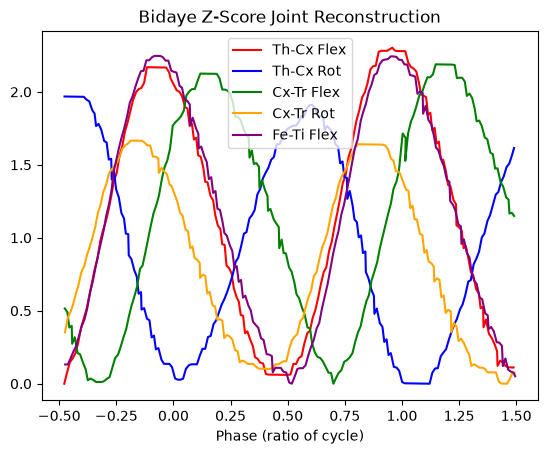

In [5]:
cx_tr_flex_data = get_joint_data('air_cx_tr_flex')
cx_tr_rot_data = get_joint_data('air_cx_tr_rot')
fe_ti_flex_data = get_joint_data('air_fe_ti_flex')
th_cx_flex_data = get_joint_data('air_th_cx_flex')
th_cx_rot_data = get_joint_data('air_th_cx_rot')

plt.figure()
plt.title('Bidaye Z-Score Joint Reconstruction')
plt.plot(th_cx_flex_data[:,0], th_cx_flex_data[:,1], label='Th-Cx Flex', color='red')
plt.plot(th_cx_rot_data[:,0], th_cx_rot_data[:,1], label='Th-Cx Rot', color='blue')
plt.plot(cx_tr_flex_data[:,0], cx_tr_flex_data[:,1], label='Cx-Tr Flex', color='green')
plt.plot(cx_tr_rot_data[:,0], cx_tr_rot_data[:,1], label='Cx-Tr Rot', color='orange')
plt.plot(fe_ti_flex_data[:,0], fe_ti_flex_data[:,1], label='Fe-Ti Flex', color='purple')
plt.legend()
plt.xlabel('Phase (ratio of cycle)')
plt.savefig('bidayeAir.svg', format='svg')
plt.show()

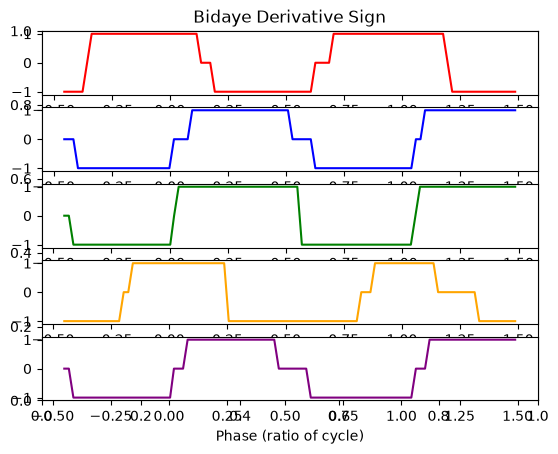

In [24]:
def filtered_sign(raw_data):
    sign_raw = np.sign(np.diff(raw_data))
    sign = sign_raw.copy()

    i = 0
    while i < len(sign):
        if sign[i] == 0:
            # Find end of zero run
            start = i
            while i < len(sign) and sign[i] == 0:
                i += 1
            end = i

            # Zero run bounded by identical nonzero values
            if start > 0 and end < len(sign):
                before = sign[start - 1]
                after = sign[end]

                if before != 0 and before == after:
                    sign[start:end] = before

        i += 1

    # Also remove single-index reversals such as -1, 1, -1
    for i in range(1, len(sign) - 1):
        if (
            sign[i - 1] != 0
            and sign[i] != sign[i - 1]
            and sign[i + 1] == sign[i - 1]
        ):
            sign[i] = sign[i - 1]

    return sign

th_cx_flex_diff = filtered_sign(th_cx_flex_data[:,1])
th_cx_rot_diff = filtered_sign(th_cx_rot_data[:,1])
cx_tr_flex_diff = filtered_sign(cx_tr_flex_data[:,1])
cx_tr_rot_diff = filtered_sign(cx_tr_rot_data[:,1])
fe_ti_flex_diff = filtered_sign(fe_ti_flex_data[:,1])

plt.figure()
plt.title('Bidaye Derivative Sign')
plt.subplot(5,1,1)
plt.plot(th_cx_flex_data[1:,0], th_cx_flex_diff, label='Th-Cx Flex', color='red')
plt.subplot(5,1,2)
plt.plot(th_cx_rot_data[1:,0], th_cx_rot_diff, label='Th-Cx Rot', color='blue')
plt.subplot(5,1,3)
plt.plot(cx_tr_flex_data[1:,0], cx_tr_flex_diff, label='Cx-Tr Flex', color='green')
plt.subplot(5,1,4)
plt.plot(cx_tr_rot_data[1:,0], cx_tr_rot_diff, label='Cx-Tr Rot', color='orange')
plt.subplot(5,1,5)
plt.plot(fe_ti_flex_data[1:,0], fe_ti_flex_diff, label='Fe-Ti Flex', color='purple')
# plt.legend()
plt.xlabel('Phase (ratio of cycle)')
plt.show()

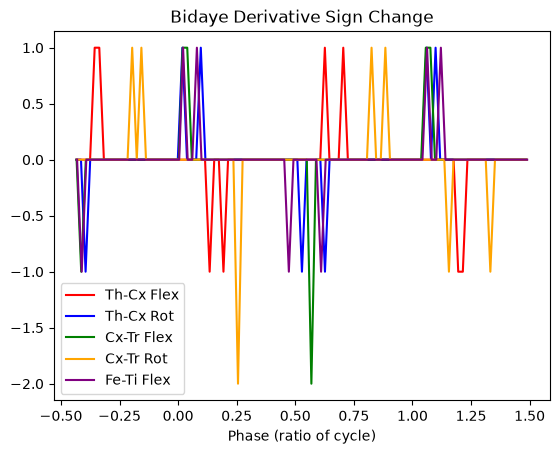

In [19]:
th_cx_flex_dir = np.diff(th_cx_flex_diff)
th_cx_rot_dir = np.diff(th_cx_rot_diff)
cx_tr_flex_dir = np.diff(cx_tr_flex_diff)
cx_tr_rot_dir = np.diff(cx_tr_rot_diff)
fe_ti_flex_dir = np.diff(fe_ti_flex_diff)
plt.figure()
plt.title('Bidaye Derivative Sign Change')
plt.plot(th_cx_flex_data[2:,0], th_cx_flex_dir, label='Th-Cx Flex', color='red')
plt.plot(th_cx_rot_data[2:,0], th_cx_rot_dir, label='Th-Cx Rot', color='blue')
plt.plot(cx_tr_flex_data[2:,0], cx_tr_flex_dir, label='Cx-Tr Flex', color='green')
plt.plot(cx_tr_rot_data[2:,0], cx_tr_rot_dir, label='Cx-Tr Rot', color='orange')
plt.plot(fe_ti_flex_data[2:,0], fe_ti_flex_dir, label='Fe-Ti Flex', color='purple')
plt.legend()
plt.xlabel('Phase (ratio of cycle)')
plt.show()

# Middle Leg

In [ ]:
th_cx_flex_data = get_joint_data('amp_th_cx_flex')